In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [5]:

# Load data
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [6]:
# 1️⃣ Single Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)

In [7]:
# 2️⃣ Random Forest (Bagging of Trees)
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
forest_preds = forest.predict(X_test)

In [8]:
# Compare accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, forest_preds))

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


In [10]:
#let me see the dataset as a dataframe
import pandas as pd
X, y = load_iris(return_X_y=True)
df = pd.DataFrame(X, columns=load_iris().feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
X, y = load_iris(return_X_y=True)
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [18]:
y
len(X)
len(y)

150

In [ ]:
l = [1,2,3,4,5]

#access the first two elements from the end of the list
l[:-3:1]

[1, 2]

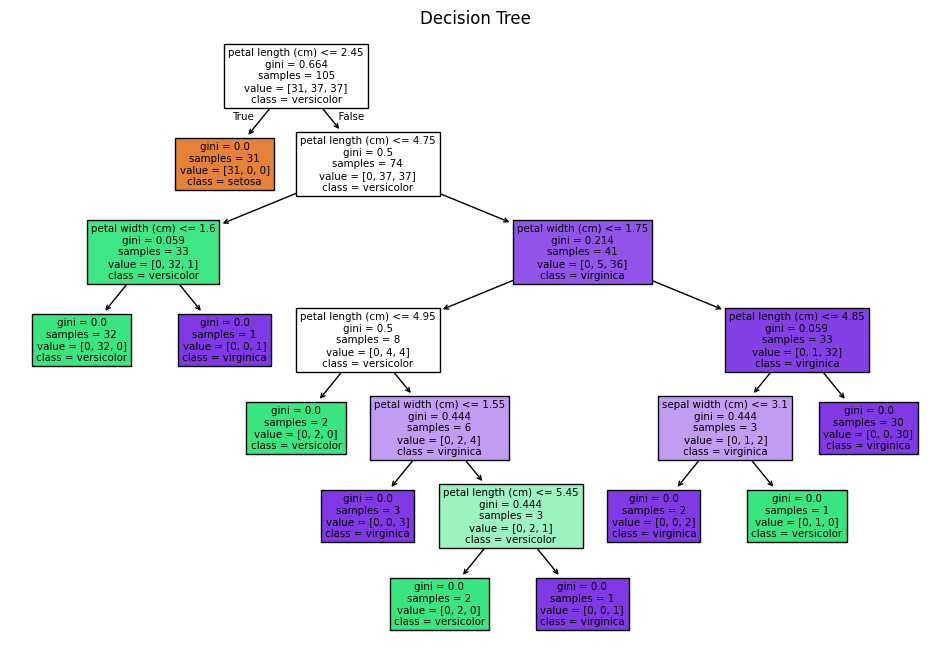

In [19]:
#nicely plot the decision tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(tree, filled=True, feature_names=load_iris().feature_names, class_names=load_iris().target_names)
plt.title("Decision Tree")
plt.show()

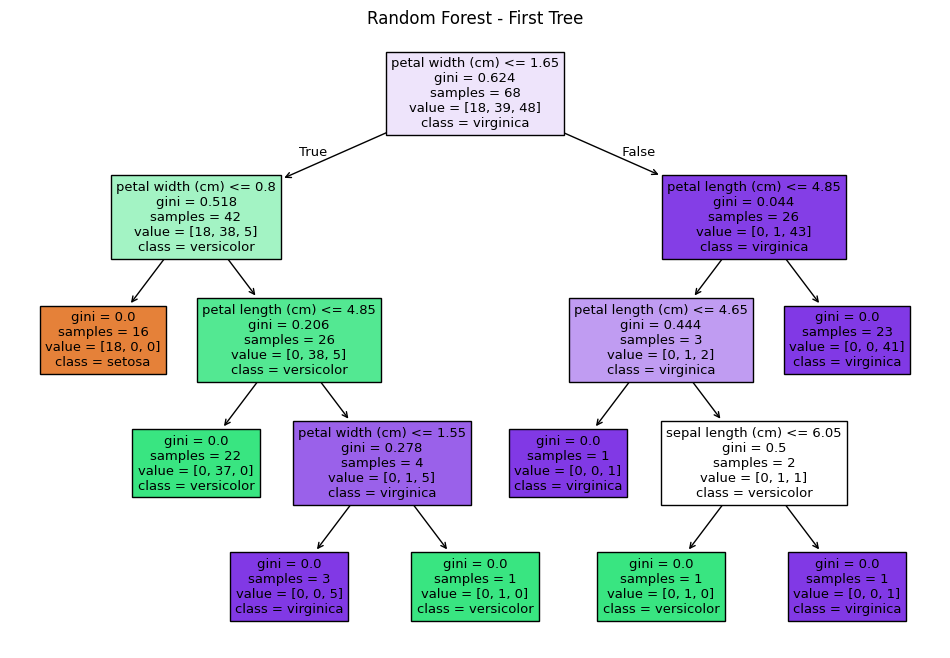

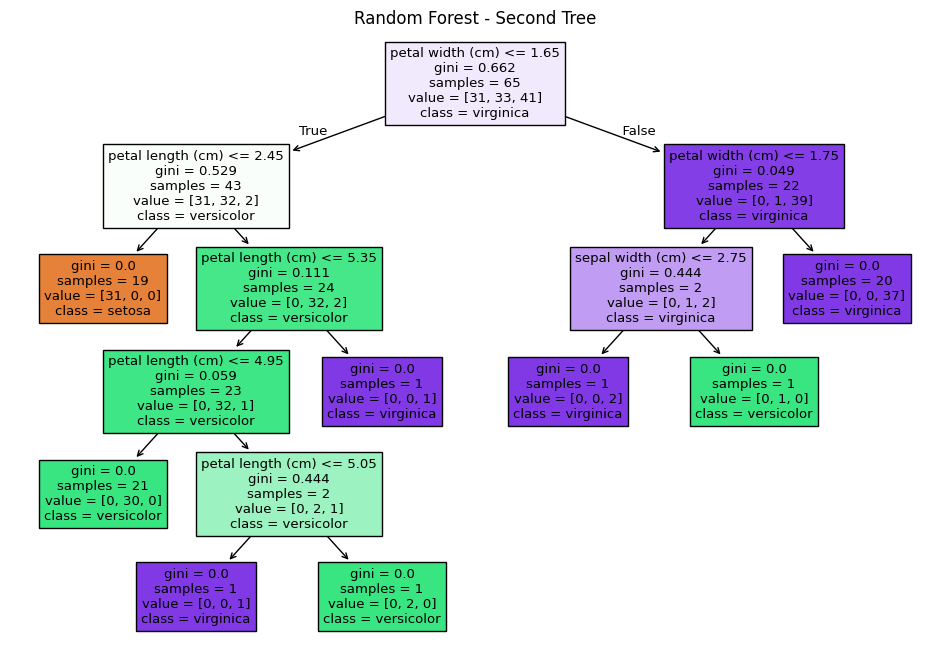

100

In [22]:
#plot the forest as well
plt.figure(figsize=(12,8))
plot_tree(forest.estimators_[0], filled=True, feature_names=load_iris().feature_names, class_names=load_iris().target_names)
plt.title("Random Forest - First Tree")
plt.show()
#plot the other trees as well
plt.figure(figsize=(12,8))
plot_tree(forest.estimators_[1], filled=True, feature_names=load_iris().feature_names, class_names=load_iris().target_names)
plt.title("Random Forest - Second Tree")
plt.show()

#length of the forest
len(forest.estimators_)

In [31]:
tree.tree_.impurity

array([0.6644898 , 0.        , 0.5       , 0.05876951, 0.        ,
       0.        , 0.21415824, 0.5       , 0.        , 0.44444444,
       0.        , 0.44444444, 0.        , 0.        , 0.05876951,
       0.44444444, 0.        , 0.        , 0.        ])

In [30]:
for i in range(tree.tree_.node_count):
    print(f"Node {i}:")
    print(f"  Feature index: {tree.tree_.feature[i]}")
    print(f"  Threshold: {tree.tree_.threshold[i]}")
    print(f"  Impurity: {tree.tree_.impurity[i]}")
    print(f"  Samples: {tree.tree_.n_node_samples[i]}")
    print()

Node 0:
  Feature index: 2
  Threshold: 2.449999988079071
  Impurity: 0.6644897959183673
  Samples: 105

Node 1:
  Feature index: -2
  Threshold: -2.0
  Impurity: 0.0
  Samples: 31

Node 2:
  Feature index: 2
  Threshold: 4.75
  Impurity: 0.5
  Samples: 74

Node 3:
  Feature index: 3
  Threshold: 1.600000023841858
  Impurity: 0.058769513314967825
  Samples: 33

Node 4:
  Feature index: -2
  Threshold: -2.0
  Impurity: 0.0
  Samples: 32

Node 5:
  Feature index: -2
  Threshold: -2.0
  Impurity: 0.0
  Samples: 1

Node 6:
  Feature index: 3
  Threshold: 1.75
  Impurity: 0.21415823914336707
  Samples: 41

Node 7:
  Feature index: 2
  Threshold: 4.950000047683716
  Impurity: 0.5
  Samples: 8

Node 8:
  Feature index: -2
  Threshold: -2.0
  Impurity: 0.0
  Samples: 2

Node 9:
  Feature index: 3
  Threshold: 1.550000011920929
  Impurity: 0.4444444444444444
  Samples: 6

Node 10:
  Feature index: -2
  Threshold: -2.0
  Impurity: 0.0
  Samples: 3

Node 11:
  Feature index: 2
  Threshold: 5.4500